In [31]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Listings.csv", encoding="latin1")


C:\Users\sabba\AppData\Local\Temp\ipykernel_37400\1630855267.py:1: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Listings.csv", encoding="latin1")


In [3]:
df.sample(5)

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
26244,46284379,Cozy Place in Manly Beach,24080707,2014-11-23,"Bordeaux, Aquitaine, France",within an hour,1.00,1.00,f,1.0,...,4,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t
138489,18525147,Confortevole camera nel centro di Roma,127987273,2017-04-28,"Rome, Lazio, Italy",within a few hours,1.00,0.56,f,11.0,...,1,1125,97.0,10.0,10.0,10.0,10.0,10.0,9.0,f
127130,6884254,Cozy quiet room off of Broadway,19789003,2014-08-10,"New York, New York, United States",NaN,NaN,NaN,f,1.0,...,30,1125,60.0,6.0,4.0,8.0,10.0,8.0,6.0,f
42032,45469423,Contemporary flat in the heart of Condesa,52517534,2015-12-28,"Mexico City, Mexico City, Mexico",within a few hours,0.89,0.80,f,0.0,...,2,1125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f
225292,36834030,Ã£â¬ÂÃ¦Â¸Â©Ã©Â¦Â¨Ã¤Â¸â¬Ã¥Â±â¦Ã£â¬âÃ©Â¡Â...,51192901,2015-12-13,"Bangkok, Thailand",within an hour,0.90,0.97,f,14.0,...,1,30,93.0,10.0,9.0,10.0,10.0,9.0,9.0,t


shape of data

In [4]:
df.shape

(279712, 33)

data type of data

In [5]:
df.info

<bound method DataFrame.info of         listing_id                                               name  \
0           281420     Beautiful Flat in le Village Montmartre, Paris   
1          3705183                    39 mÃÂ² Paris (Sacre CÃ
âur)   
2          4082273                Lovely apartment with Terrace, 60m2   
3          4797344                Cosy studio (close to Eiffel tower)   
4          4823489   Close to Eiffel Tower - Beautiful flat : 2 rooms   
...            ...                                                ...   
279707    38338635  Appartement T2 neuf prÃÂ¨s du tram T3a Porte ...   
279708    38538692                          Cozy Studio in Montmartre   
279709    38683356            Nice and cosy mini-appartement in Paris   
279710    39659000  Charming apartment near Rue Saint Maur / Oberk...   
279711    40219504        Cosy apartment with view on Canal St Martin   

         host_id  host_since                 host_location host_response_time  \
0        1

missing values

In [6]:
df.isna().sum()

listing_id                          0
name                              175
host_id                             0
host_since                        165
host_location                     840
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
host_is_superhost                 165
host_total_listings_count         165
host_has_profile_pic              165
host_identity_verified            165
neighbourhood                       0
district                       242700
city                                0
latitude                            0
longitude                           0
property_type                       0
room_type                           0
accommodates                        0
bedrooms                        29435
amenities                           0
price                               0
minimum_nights                      0
maximum_nights                      0
review_scores_rating            91405
review_score

how does the data look mathematicaly

In [7]:
df.describe()

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.797120e+05,2.797120e+05,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,2.638196e+07,1.081658e+08,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,1.442576e+07,1.108570e+08,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,3441.826611,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,2.577000e+03,1.822000e+03,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.384462e+07,1.720656e+07,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,75.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.767098e+07,5.826911e+07,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,150.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.978485e+07,1.832853e+08,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,474.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.834353e+07,3.901874e+08,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


duplicate

In [8]:
df.duplicated().sum()

np.int64(0)

how is the correlation between cols

In [9]:
df.corr(numeric_only=True)

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
listing_id,1.000000,0.582679,-0.014195,0.109949,0.071972,-0.012022,-0.001949,-0.005969,0.006881,0.011471,-0.034967,-0.005873,-0.026382,-0.047476,-0.025831,-0.065647,-0.067393,0.016243,-0.020410
host_id,0.582679,1.000000,-0.082474,0.122923,0.015198,0.005266,0.008961,-0.014839,-0.001526,0.011795,-0.038348,-0.003148,-0.089288,-0.095226,-0.055538,-0.100904,-0.103973,-0.046701,-0.067068
host_response_rate,-0.014195,-0.082474,1.000000,0.321510,0.037986,-0.015872,-0.018426,0.012068,-0.007806,-0.000697,-0.012630,0.000048,0.112409,0.108358,0.118284,0.106289,0.120641,0.091927,0.099234
host_acceptance_rate,0.109949,0.122923,0.321510,1.000000,0.034085,0.073135,-0.003525,-0.008704,-0.045264,-0.039315,-0.045547,0.000307,-0.017294,-0.007801,0.028197,-0.013868,-0.011385,0.005349,0.000529
host_total_listings_count,0.071972,0.015198,0.037986,0.034085,1.000000,-0.042281,0.061737,-0.018868,-0.009910,0.009907,-0.000161,-0.000303,-0.037162,-0.040658,-0.016856,-0.036414,-0.045739,-0.005259,-0.049027
latitude,-0.012022,0.005266,-0.015872,0.073135,-0.042281,1.000000,-0.417783,-0.111880,-0.137463,-0.099278,0.046801,0.001569,-0.034199,-0.007049,-0.035079,-0.023368,-0.011368,-0.043589,-0.022222
longitude,-0.001949,0.008961,-0.018426,-0.003525,0.061737,-0.417783,1.000000,0.009465,0.037800,0.019608,-0.056316,-0.001410,-0.048905,-0.052181,-0.045029,-0.043660,-0.033794,-0.052074,-0.039725
accommodates,-0.005969,-0.014839,0.012068,-0.008704,-0.018868,-0.111880,0.009465,1.000000,0.639102,0.146327,-0.033442,0.003241,0.006420,-0.009308,0.007203,0.004743,-0.000910,0.008774,-0.023706
bedrooms,0.006881,-0.001526,-0.007806,-0.045264,-0.009910,-0.137463,0.037800,0.639102,1.000000,0.143307,-0.010582,0.000872,0.009007,-0.010811,0.002247,0.005562,-0.004753,0.008412,-0.019745
price,0.011471,0.011795,-0.000697,-0.039315,0.009907,-0.099278,0.019608,0.146327,0.143307,1.000000,0.006344,-0.000442,0.015048,-0.000693,0.024328,-0.000243,-0.003262,-0.000609,0.001572


In [10]:
df['name'] = df['name'].fillna('Unknown')
df['name']

0            Beautiful Flat in le Village Montmartre, Paris
1                           39 mÃÂ² Paris (Sacre CÃ
âur)
2                       Lovely apartment with Terrace, 60m2
3                       Cosy studio (close to Eiffel tower)
4          Close to Eiffel Tower - Beautiful flat : 2 rooms
                                ...                        
279707    Appartement T2 neuf prÃÂ¨s du tram T3a Porte ...
279708                            Cozy Studio in Montmartre
279709              Nice and cosy mini-appartement in Paris
279710    Charming apartment near Rue Saint Maur / Oberk...
279711          Cosy apartment with view on Canal St Martin
Name: name, Length: 279712, dtype: str

In [11]:
df['host_since'] = df['host_since'].ffill()


In [12]:
df['host_location'] = df['host_location'].ffill()


In [13]:
df['host_response_time'] = df['host_response_time'].ffill()


In [14]:
df['host_response_time'] = df['host_response_time'].fillna("within an hour")


In [15]:
df['host_response_rate'] = df['host_response_rate'].fillna(1)


In [16]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].ffill()


In [17]:
df['host_acceptance_rate'] = df['host_acceptance_rate'].fillna(1)


In [18]:
df['host_is_superhost'] = df['host_is_superhost'].ffill()


In [19]:
df['host_total_listings_count'] = df['host_total_listings_count'].ffill()


In [20]:
df['host_has_profile_pic'] = df['host_has_profile_pic'].ffill()


In [21]:
df['host_identity_verified'] = df['host_identity_verified'].ffill()


In [22]:
pd.set_option('display.max_columns', None)

In [23]:
df['bedrooms'] = df['bedrooms'].ffill()


In [24]:
df['review_scores_communication'] = df['review_scores_communication'].ffill()
df['review_scores_location'] = df['review_scores_location'].ffill()
df['review_scores_value'] = df['review_scores_value'].ffill()



In [25]:
df['district'] = df['district'].fillna("unkonwn")


In [26]:
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Buttes-Montmartre,unkonwn,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Buttes-Montmartre,unkonwn,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Elysee,unkonwn,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Vaugirard,unkonwn,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Passy,unkonwn,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [27]:
df.isna().sum()

listing_id                         0
name                               0
host_id                            0
host_since                         0
host_location                      0
host_response_time                 0
host_response_rate                 0
host_acceptance_rate               0
host_is_superhost                  0
host_total_listings_count          0
host_has_profile_pic               0
host_identity_verified             0
neighbourhood                      0
district                           0
city                               0
latitude                           0
longitude                          0
property_type                      0
room_type                          0
accommodates                       0
bedrooms                           0
amenities                          0
price                              0
minimum_nights                     0
maximum_nights                     0
review_scores_rating           91405
review_scores_accuracy         91713
r

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279712 non-null  str    
 2   host_id                      279712 non-null  int64  
 3   host_since                   279712 non-null  str    
 4   host_location                279712 non-null  str    
 5   host_response_time           279712 non-null  str    
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_is_superhost            279712 non-null  str    
 9   host_total_listings_count    279712 non-null  float64
 10  host_has_profile_pic         279712 non-null  str    
 11  host_identity_verified       279712 non-null  str    
 12  neighbourhood                279712 non-null  str    
 13  district  

In [29]:
df["host_since"] = pd.to_datetime(df["host_since"])

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279712 non-null  str           
 2   host_id                      279712 non-null  int64         
 3   host_since                   279712 non-null  datetime64[us]
 4   host_location                279712 non-null  str           
 5   host_response_time           279712 non-null  str           
 6   host_response_rate           279712 non-null  float64       
 7   host_acceptance_rate         279712 non-null  float64       
 8   host_is_superhost            279712 non-null  str           
 9   host_total_listings_count    279712 non-null  float64       
 10  host_has_profile_pic         279712 non-null  str           
 11  host_identity_verified       279712 n

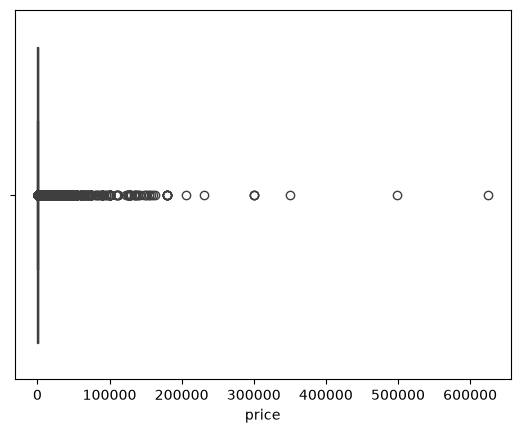

In [32]:
sns.boxplot(x=df["price"])
plt.show()

In [35]:
df["price"].sort_values(ascending=False).head(20)

181027    625216
162251    499000
98808     350000
135705    300177
218597    300000
182185    300000
44906     231047
196424    206499
97609     180124
208690    180000
97235     180000
212865    180000
147928    179532
147929    179532
151827    179532
148392    179153
60914     163502
262274    160000
97240     157500
206101    155000
Name: price, dtype: int64

In [36]:
df.loc[df["price"].nlargest(20).index, 
       ["listing_id", "name", "city", "property_type", "room_type", "accommodates", "price"]]

,listing_id,name,city,property_type,room_type,accommodates,price
181027,13879989,Temporary rentals for Brazilian Cup.,Rio de Janeiro,Shared room in house,Shared room,5,625216
162251,47885441,Hotel Boutique Maison Salamanca,Mexico City,Room in boutique hotel,Private room,4,499000
98808,23895520,Habitacion a 40min del centro historico,Mexico City,Private room in house,Private room,4,350000
135705,3410763,Amazing view and pool in center Bkk,Bangkok,Private room in apartment,Private room,2,300177
182185,13033135,Airport-MRT-ShowShopFood-FullFN,Bangkok,Private room in house,Private room,4,300000
218597,12056763,Charoenkrung Road House/Office Rent,Bangkok,Entire house,Entire place,4,300000
44906,29970931,Ã¥â¦Â¬Ã¥Â¯â,Bangkok,Entire apartment,Entire place,2,231047
196424,38733276,Room in the most exclusive area in Mexico City,Mexico City,Private room in apartment,Private room,1,206499
97609,41578696,Ã¥Â¥Â¢Ã¥ÂÅ½Ã§Â§ÂÃ¥Â®Â¶Ã¥ÂºâÃ¥âºÂ­Ã¯Â¼ÅÃ¤...,Bangkok,Entire villa,Entire place,10,180124
97235,24231503,Beyond,Cape Town,Entire villa,Entire place,10,180000


In [37]:
df["price"].describe()

count    279712.000000
mean        608.792737
std        3441.826611
min           0.000000
25%          75.000000
50%         150.000000
75%         474.000000
max      625216.000000
Name: price, dtype: float64

In [39]:
print("Mean:", df["price"].mean())
print("Median:", df["price"].median())

Mean: 608.7927368150097
Median: 150.0


In [40]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower)
print("Upper limit:", upper)

Q1: 75.0
Q3: 474.0
IQR: 399.0
Lower limit: -523.5
Upper limit: 1072.5


In [41]:
outliers = df[df["price"] > upper]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Number of outliers: 31395
Percentage of outliers: 11.224044731724058


In [42]:
outliers["price"].describe()

count     31395.000000
mean       3585.325115
std        9752.161067
min        1073.000000
25%        1361.000000
50%        1850.000000
75%        3000.000000
max      625216.000000
Name: price, dtype: float64

In [43]:
df[df["price"] <= upper]["price"].describe()

count    248317.000000
mean        232.466372
std         241.398742
min           0.000000
25%          70.000000
50%         125.000000
75%         300.000000
max        1072.000000
Name: price, dtype: float64

In [44]:
print("Price = 0:", (df["price"] == 0).sum())
print("Percentage:", (df["price"] == 0).mean() * 100)

Price = 0: 113
Percentage: 0.040398695801395726


In [45]:
df[df["price"] == 0][
    ["listing_id", "name", "city", "property_type", "room_type", "price"]
].head(20)

,listing_id,name,city,property_type,room_type,price
98209,44312919,Bienvenue ÃÂ l'HÃÂ´tel des 3 CollÃÂ¨ges,Paris,Room in boutique hotel,Hotel room,0
202022,42830099,Hotel Hugo,New York,Room in boutique hotel,Hotel room,0
202023,43247472,Hotel 57,New York,Room in boutique hotel,Hotel room,0
203253,43205598,Wellington Hotel,New York,Room in boutique hotel,Hotel room,0
203254,44567521,"The Standard, East Village",New York,Room in boutique hotel,Hotel room,0
203255,45985185,Hotel Scherman,New York,Room in boutique hotel,Hotel room,0
203256,46251446,citizenM New York Bowery,New York,Room in boutique hotel,Hotel room,0
203257,43012882,Timhotel Paris Berthier,Paris,Room in hotel,Hotel room,0
203258,43035744,Le Pigalle,Paris,Room in boutique hotel,Hotel room,0
203259,43274767,Hotel MAYET,Paris,Room in boutique hotel,Hotel room,0


In [47]:

df = df[df["price"] > 0].copy()
df

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,district,city,latitude,longitude,property_type,room_type,accommodates,bedrooms,amenities,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Buttes-Montmartre,unkonwn,Paris,48.88668,2.33343,Entire apartment,Entire place,2,1.0,"[""Heating"", ""Kitchen"", ""Washer"", ""Wifi"", ""Long...",53,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Buttes-Montmartre,unkonwn,Paris,48.88617,2.34515,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Heating"", ""Kitchen"", ""Essentials""...",120,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Elysee,unkonwn,Paris,48.88112,2.31712,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Washer"", ""Wifi"",...",89,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Vaugirard,unkonwn,Paris,48.84571,2.30584,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Wifi"", ""Long ter...",58,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,f,Passy,unkonwn,Paris,48.85500,2.26979,Entire apartment,Entire place,2,1.0,"[""Heating"", ""TV"", ""Kitchen"", ""Essentials"", ""Ha...",60,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279707,38338635,Appartement T2 neuf prÃÂ¨s du tram T3a Porte ...,31161181,2015-04-13,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Observatoire,unkonwn,Paris,48.82701,2.31419,Entire apartment,Entire place,2,1.0,"[""Iron"", ""Heating"", ""Washer"", ""Dedicated works...",120,1,7,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279708,38538692,Cozy Studio in Montmartre,10294858,2013-11-27,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Buttes-Montmartre,unkonwn,Paris,48.89309,2.33206,Entire apartment,Entire place,2,1.0,"[""Shampoo"", ""Iron"", ""Heating"", ""Washer"", ""Hair...",60,7,15,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279709,38683356,Nice and cosy mini-appartement in Paris,2238502,2012-04-27,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Buttes-Montmartre,unkonwn,Paris,48.88699,2.34920,Entire apartment,Entire place,2,1.0,"[""Paid parking off premises"", ""Shampoo"", ""Firs...",50,6,30,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
279710,39659000,Charming apartment near Rue Saint Maur / Oberk...,38633695,2015-07-16,"Paris, Ile-de-France, France",within an hour,1.0,1.0,f,1.0,t,t,Popincourt,unkonwn,Paris,48.86687,2.38123,Entire apartment,Entire place,2,1.0,"[""TV"", ""Iron"", ""Kitchen"", ""Hangers"", ""Smoke al...",105,3,18,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [48]:
print(df["price"].min())
print(df.shape)

1
(279599, 33)


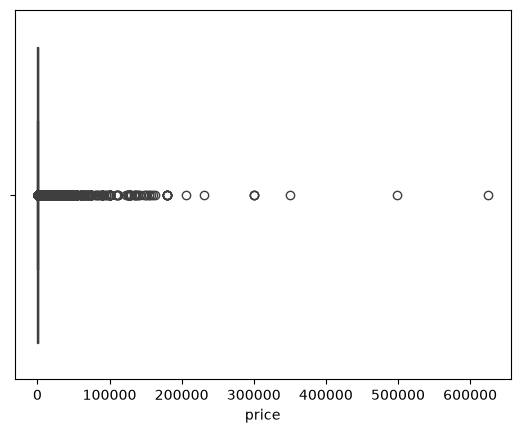

In [49]:
sns.boxplot(x=df["price"])
plt.show()

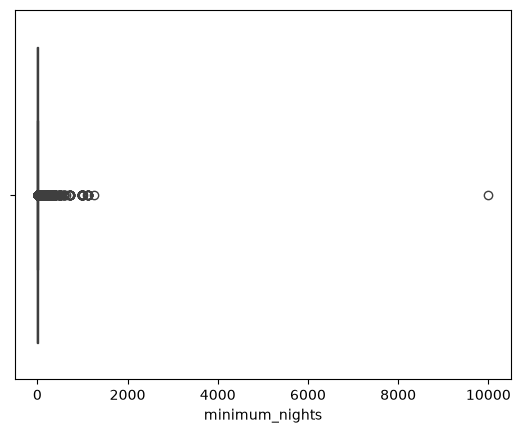

In [33]:
sns.boxplot(x=df["minimum_nights"])
plt.show()

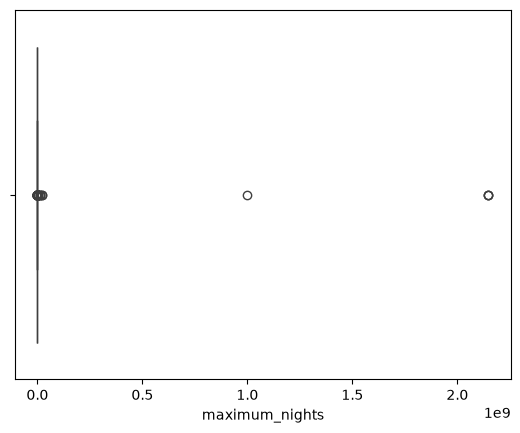

In [34]:
sns.boxplot(x=df["maximum_nights"])
plt.show()